In [1]:
from scipy.io.wavfile import read, write
from IPython.display import Audio


Fs, data = read('harvard_sentence.wav')

data = data[13000:330000]
#data=data[15500:17500]  #this says "paint"

Audio(data, rate=Fs)

In [4]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import time
import numpy as np
import pickle 
import brian2 as b2
import brian2hears as b2h
import matplotlib.pyplot as plt
#import csv
import os.path
from os import path
%matplotlib inline
from preprocess import preprocessing as pre

In [5]:
cfmin, cfmax, cfN = 50*b2.Hz, 3*b2.kHz, 100
# 72 chemosensors, but changing to 100 leads to finer frequencies and the network still works
# 50 to 3000 Hz because normal human speech is within these frequencies
cf = b2h.erbspace(cfmin, cfmax, cfN)
sound = b2h.loadsound('harvard_sentence.wav')
sound.save('harvard_sentence.wav')

sound = sound[13000:330000]
gfb = b2h.Gammatone(sound, cf)
ihc = b2h.FunctionFilterbank(gfb, lambda x: 3*clip(x, 0, Inf)**(1.0/3.0))
# Leaky integrate-and-fire model with noise and refractoriness
eqs = '''
dv/dt = (I-v)/(1*ms)+0.2*xi*(2/(1*ms))**.5 : 1 (unless refractory)
I : 1
'''
G = b2h.FilterbankGroup(ihc, 'I', eqs, reset='v=0', threshold='v>1', refractory=5*b2.ms)

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


testOdorList3.txt exists


Text(0.5,0,'Time (index)')

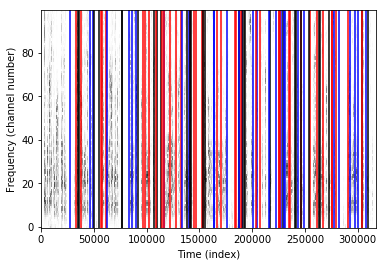

In [4]:
X = np.abs(gfb.process().T)
#X[30:,:]*=3
X = np.log(X+.01)
X += X.min()
plt.imshow(X,aspect='auto', origin='lower left')

xcoords = np.array([500,750,1050,1250, 1600,1800,2000,2500,2800,3000])*8
# change xcoords2 to be after xcoords.max +1000 
xcoords2 = np.random.randint(3000*8+1000,317001, size=100)
testDataName = "testOdorList3.txt"
# check if testDataName exists. If it exists, load it. If it doesn't exist, continue with creating the file as below
if path.exists(testDataName):
    xcoords2 = np.loadtxt(testDataName)
    print(testDataName+" exists")
'''
with open(testDataName,"r") as csv_file:
    reader = csv.reader(csvfile, delimiter=' ')
    for item in xcoords2:
        file.read('%s,'%item)
'''        
colors = ['r','k','b','r','k','b','r','k','b','r']*10
for xc,c in zip(xcoords2,colors):
    plt.axvline(x=xc, label='line at x = {}'.format(xc), c=c)

'''
scale_factor = 72/5000
plt.ylim(0,72)
'''
#locs, labels = yticks()
#xticks()
plt.set_cmap('gray_r')
plt.ylabel('Frequency (channel number)')
plt.xlabel('Time (index)')


In [5]:
pre.X_index(X, xcoords, xcoords2)


nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

IndexError: arrays used as indices must be of integer (or boolean) type

In [6]:
from lib import epl 



#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
t1 = time.time(); 
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1,nGammaPerOdor = 10); 
    # changed nGammaPerOdor from 5 to 10
    epl.GClayer.invokeNeurogenesis();
    sniff(trainingOdors[i], learn_flag=0);

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 
    if(i%10==0 and i!=0):
        print(str(i) + " odors tested"); 
t2 = time.time(); 
print("Simulation Duration = " + str(t2-t1) + "s")

#Readout
# has summary of a lot of the results
# find structure of sMatrix and summarize the performance for a particular run

sMatrix = readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  
f=open('sMatrix.txt','a',fmt='%i',delimiter=', ')
np.savetxt(f,sMatrix)
f.close()
#Plots
plots.plotFigure4a(epl.gammaCode); 
plt.savefig('fig4a:testOdorList3.png')  #SAVING FIGURES to png files
plots.plotFigure4b(sMatrix); 
plt.savefig('fig4b:testOdorList3.png')

plots.plotFigure4d(epl.gammaCode, sMatrix); 


NameError: name 'trainingOdors' is not defined

Tasks:
- write testDataName 100 length random integers (create 5 and save if better results than others)
- change nGammaPerOdor from 5 to 10 (and save results in a file)
- find the average levels of recognition in readout.py


Variables:
- dataset (testOdorsList)
- nGammaPerOdor (5 --> 10)
- scale = 10 (from import epl cell)

average levels of recognition = %


In [11]:
X.shape

(100L, 317000L)